In [46]:
import os
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from matplotlib import colors
load_dotenv()
%matplotlib inline
%config InlineBackend.figure_format = "retina"


# Overview

This notebook validates our implementation against the reference study in `papers/main.pdf`.

What we do:
- Implement the non-dimensional rotor/stator rubbing model described in the paper (see `../model/README.md`).
- Simulate it using our custom adaptive RK45 solver (see `../core/README.md`).
- Reproduce the paper’s baseline case and then run a controlled sweep in non-dimensional speed $\bar{\omega}$ to capture the transition from free-whirl to rubbing-dominated motion.

How we compare with the paper:
- **Time history of orbit radius** $R(\tau)$: growth during transient and saturation once contact activates near the clearance boundary $R=1$.
- **Phase portrait (orbit)**: change from nearly circular free whirl to a distorted orbit constrained by the clearance circle.
- **Contact/penetration diagnostics**: contact becomes intermittent/continuous depending on $\bar{\omega}$ and eccentricity $e_{bar}$.

> Note: raw simulation data is not committed to the repository. Generate it locally (see project `README.md`) or point the notebook to existing files via `.env`.


In [47]:
##Don't run this notebook before getting the simulation data

# Inputs (override with .env if desired)
PAPER_TRAJECTORY = os.environ.get('PAPER_TRAJECTORY', '../results/raw/paper_reproduction.npz')
PAPER_METADATA = os.environ.get('PAPER_METADATA', '../results/metadata/paper_meta_file.csv')
SWEEP_METADATA = os.environ.get('SWEEP_METADATA', '../results/metadata/omega_sweep.csv')

## Just to check the environment 
for p in [PAPER_TRAJECTORY, PAPER_METADATA, SWEEP_METADATA]:
    if p is None:
        continue
    if not os.path.exists(p):
        raise FileNotFoundError(
            f"Missing input file: {p}. Set it via .env (PAPER_TRAJECTORY/PAPER_METADATA/SWEEP_METADATA) "
            "or generate results under ../results/."
        )

print('PAPER_TRAJECTORY:', PAPER_TRAJECTORY)
print('PAPER_METADATA:  ', PAPER_METADATA)
print('SWEEP_METADATA:  ', SWEEP_METADATA)

paper_trajectory = np.load(PAPER_TRAJECTORY)
paper_metadata = pd.read_csv(PAPER_METADATA)

# trajectory arrays
_t = paper_trajectory['t']
_y = paper_trajectory['y']

t = _t
X, Y = _y[:, 0], _y[:, 1]
R = np.sqrt(X**2 + Y**2)
Xdot, Ydot = _y[:, 2], _y[:, 3]

paper_metadata.head()


PAPER_TRAJECTORY: /Users/harikesh/Documents/Numerical Simulations/1-DOF_Project/results/raw/paper_reproduction.npz
PAPER_METADATA:   /Users/harikesh/Documents/Numerical Simulations/1-DOF_Project/results/metadata/paper_meta_file.csv
SWEEP_METADATA:   /Users/harikesh/Documents/Numerical Simulations/1-DOF_Project/results/metadata/omega_sweep.csv


,f_shaft,ecc,kc,mu,r_disk,R_mean,R_std,R_max,R_min,contact_ratio,...,y_std,orbit_dispersion,x_dom_freq,x_dom_amp,y_dom_freq,y_dom_amp,whirl_freq,spectral_entropy,crest_factor,Omega_bar
0,50.0,0.0005,690872.308076,0.01,0.01,1.062028,0.080106,1.303669,0.01,0.968,...,0.753487,1.78178,0.159075,1.088856e+06,0.159075,1.099009e+06,0.159075,6.725517,13.132895,1.0


In [48]:
df = pd.read_csv(SWEEP_METADATA)
# Handle older files that may include an index column
if any(col.startswith('Unnamed') for col in df.columns):
    df = df.loc[:, ~df.columns.str.startswith('Unnamed')]

df.head()


,f_shaft,ecc,kc,mu,r_disk,R_mean,R_std,R_max,R_min,contact_ratio,...,orbit_dispersion,x_dom_freq,x_dom_amp,y_dom_freq,y_dom_amp,whirl_freq,spectral_entropy,crest_factor,Omega_bar,e_bar
0,25.0,0.000100,690872.308076,0.01,0.01,0.033259,8.226890e-08,0.033260,0.033259,0.0,...,0.001734,0.08484,43.614683,0.074235,42.548045,0.079538,5.022074,4.764294,0.5,0.100000
1,25.0,0.000178,690872.308076,0.01,0.01,0.059128,1.647506e-07,0.059129,0.059127,0.0,...,0.005482,0.08484,137.843932,0.074235,134.472840,0.079538,4.187635,4.950316,0.5,0.177778
2,25.0,0.000256,690872.308076,0.01,0.01,0.084996,2.477385e-07,0.084998,0.084996,0.0,...,0.011328,0.08484,284.841555,0.074235,277.875522,0.079538,3.980335,5.069106,0.5,0.255556
3,25.0,0.000333,690872.308076,0.01,0.01,0.110865,3.306211e-07,0.110867,0.110864,0.0,...,0.019272,0.08484,484.607558,0.074235,472.756093,0.079538,3.889521,5.045802,0.5,0.333333
4,25.0,0.000411,690872.308076,0.01,0.01,0.136733,4.136079e-07,0.136736,0.136732,0.0,...,0.029315,0.08484,737.141946,0.074235,719.114554,0.079538,3.863358,5.057552,0.5,0.411111


In [49]:
R

array([0.01      , 0.01599786, 0.03365253, ..., 1.06961863, 1.06961836,
       1.06961869])

In [50]:
paper_metadata['f_shaft']

0    50.0
Name: f_shaft, dtype: float64

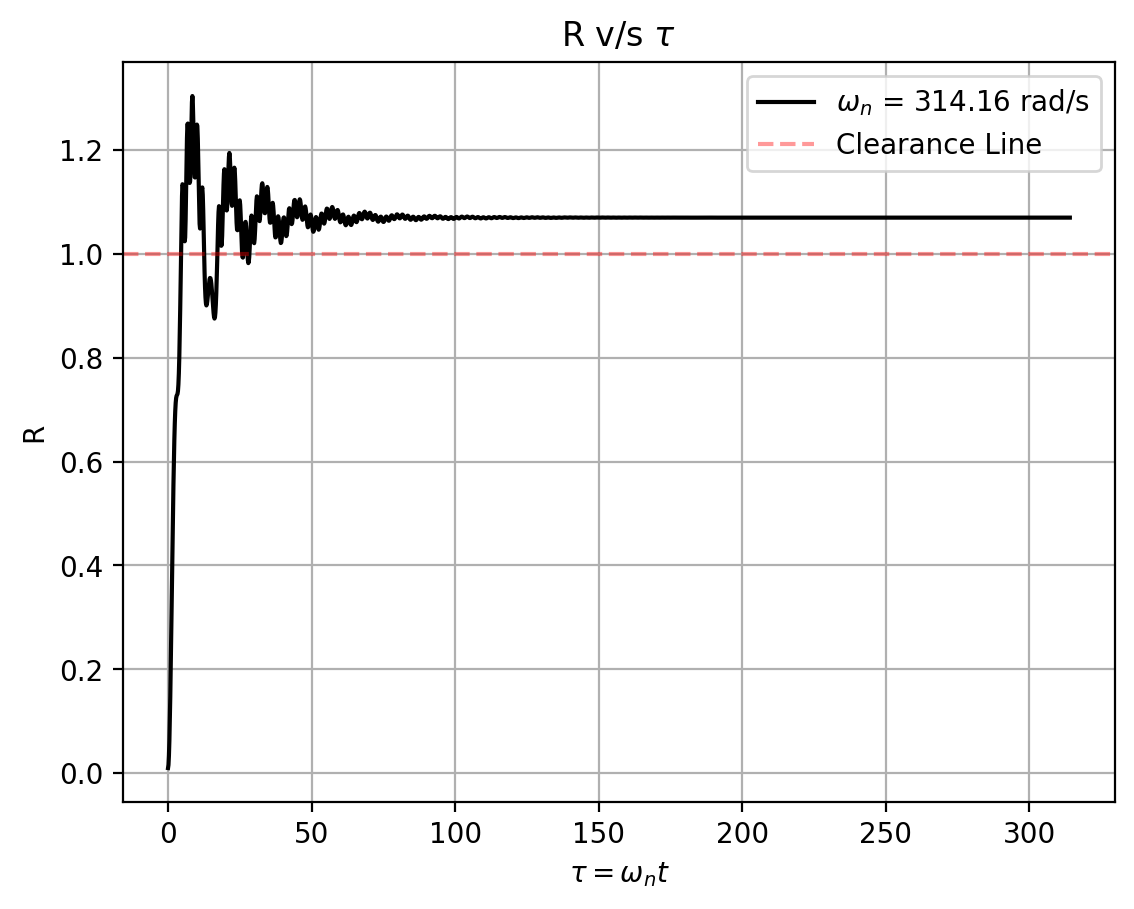

In [51]:
## trajectory evolution

plt.plot(t,R,color='k',label=r'$\omega_n$ = {omega:.2f} rad/s'.format(omega=2*np.pi*paper_metadata['f_shaft'].item()))
plt.title(r"R v/s $\tau$")
plt.xlabel(r"$\tau = \omega_n t$")
# plt.text(200,1.25)
plt.ylabel('R')
plt.axhline(y=1.0,color='red',linestyle='--',alpha=0.4,label='Clearance Line')
plt.legend()
plt.grid()
plt.show()

### Paper reference (validation)

- Compare this **amplitude build-up and saturation** behavior against `papers/main.pdf` **Fig. 12** (PDF p. 9): *Comparison of non-dimensional amplitude between rotors with and without rub-impact*.
- The key qualitative match is: growth near the critical region, then **rubbing/constraint limits further amplitude** once contact becomes active (clearance boundary effect).


> In the baseline case, the orbit radius grows during the initial transient (near-resonant response), consistent with the paper’s reported build-up toward the clearance boundary.

> Once $R$ approaches the clearance line ($R=1$), contact forces activate and the response amplitude is limited by the non-linear rubbing interaction. This matches the qualitative “growth then saturation” behavior shown in the paper.


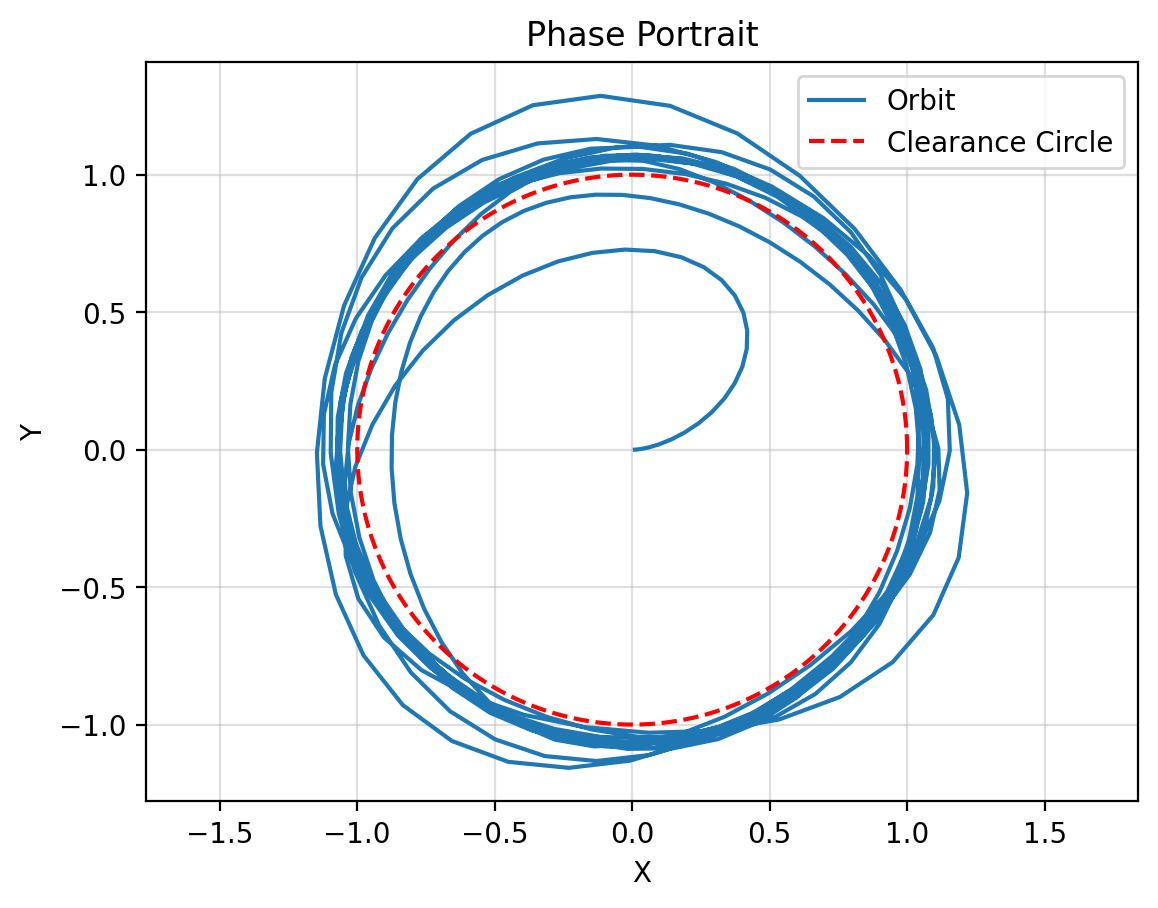

In [52]:
##Orbit plot
theta = np.linspace(0,2*np.pi,1000)
plt.plot(X,Y,label='Orbit')
plt.plot(np.cos(theta),np.sin(theta),label='Clearance Circle',color='red',linestyle='--')
plt.axis('equal')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(alpha=0.4)
plt.title("Phase Portrait")
plt.legend()
plt.show()

### Paper reference (validation)

- Compare the **orbit shape change** against `papers/main.pdf` **Fig. 13** (PDF p. 10): *Rotor axis orbits and constraint stiffness at different rotation speed ratios*.
- For experimental corroboration of orbit distortion in rubbing states, see `papers/main.pdf` **Fig. 17** (PDF p. 12): *Rotor orbits measured for different rubbing states*.


> The phase portrait illustrates the same mechanism described in the paper: an initially smooth/free-whirl orbit transitions into a clearance-limited trajectory once rubbing engages.

> The distorted shape and clipping near the clearance circle are the expected signatures of intermittent/continuous contact.


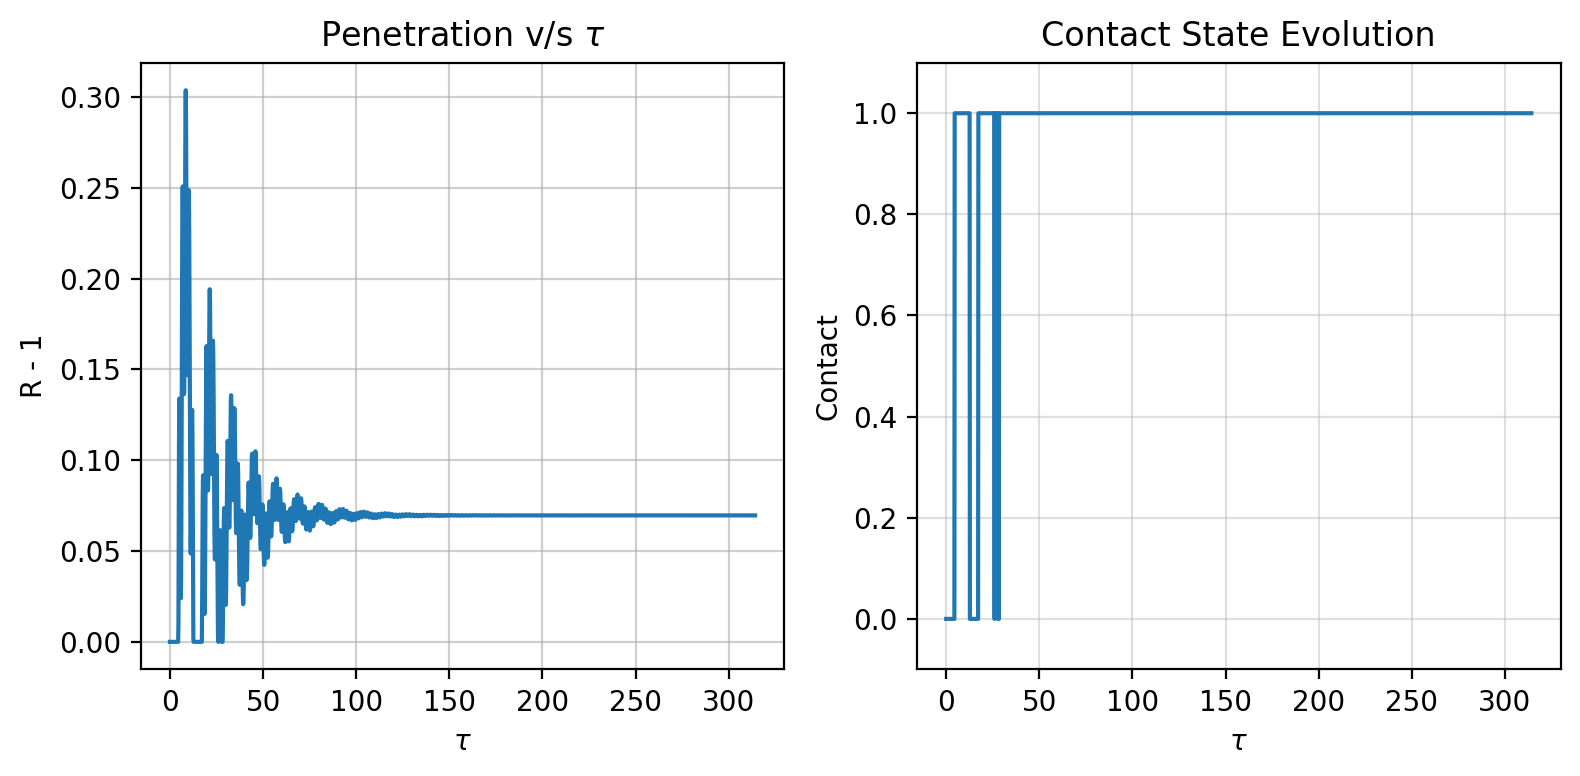

In [53]:
fig,ax = plt.subplots(1,2,figsize=(8,4))

penetration = np.clip(R - 1.0,0.0,float('inf'))
plt.sca(ax[0])
plt.plot(t,penetration)
plt.title(r'Penetration v/s $\tau$')
plt.ylabel('R - 1')
plt.xlabel(r'$\tau$')
plt.grid(alpha=0.6)


contact = (R > 1.0).astype(float)
plt.sca(ax[1])
plt.plot(t, contact)
plt.ylim(-0.1, 1.1)
plt.title("Contact State Evolution")
plt.xlabel(r'$\tau$')
plt.ylabel('Contact')
plt.grid(alpha=0.4)

plt.tight_layout()

### Paper reference (validation)

- The paper explicitly links **orbit evolution** and **contact/constraint stiffness variation** versus speed ratio in `papers/main.pdf` **Fig. 13** (PDF p. 10).
- Your penetration/contact traces are the notebook’s analog of the paper’s “constraint stiffness/contact state” diagnostic.


# Omega Sweep Analysis

In this sweep we vary non-dimensional speed $\bar{\omega}$ (and repeat across multiple $e_{bar}$ values) while keeping other parameters fixed.

What to look for (paper-consistent trends):
- Near the critical region ($\bar{\omega}\approx 1$), the mean orbit radius and variability increase, indicating a transition toward larger whirl and onset of rubbing.
- Mean penetration and contact metrics increase when $R$ exceeds the clearance boundary, and typically strengthen with larger $e_{bar}$.
- Frequency-domain features (dominant frequency/amplitude in $X$ and $Y$) should show stronger components around the critical region and under heavier rubbing.


In [54]:
df = pd.read_csv(SWEEP_METADATA)
# Handle older files that may include an index column
if any(col.startswith('Unnamed') for col in df.columns):
    df = df.loc[:, ~df.columns.str.startswith('Unnamed')]

df.head()


,f_shaft,ecc,kc,mu,r_disk,R_mean,R_std,R_max,R_min,contact_ratio,...,orbit_dispersion,x_dom_freq,x_dom_amp,y_dom_freq,y_dom_amp,whirl_freq,spectral_entropy,crest_factor,Omega_bar,e_bar
0,25.0,0.000100,690872.308076,0.01,0.01,0.033259,8.226890e-08,0.033260,0.033259,0.0,...,0.001734,0.08484,43.614683,0.074235,42.548045,0.079538,5.022074,4.764294,0.5,0.100000
1,25.0,0.000178,690872.308076,0.01,0.01,0.059128,1.647506e-07,0.059129,0.059127,0.0,...,0.005482,0.08484,137.843932,0.074235,134.472840,0.079538,4.187635,4.950316,0.5,0.177778
2,25.0,0.000256,690872.308076,0.01,0.01,0.084996,2.477385e-07,0.084998,0.084996,0.0,...,0.011328,0.08484,284.841555,0.074235,277.875522,0.079538,3.980335,5.069106,0.5,0.255556
3,25.0,0.000333,690872.308076,0.01,0.01,0.110865,3.306211e-07,0.110867,0.110864,0.0,...,0.019272,0.08484,484.607558,0.074235,472.756093,0.079538,3.889521,5.045802,0.5,0.333333
4,25.0,0.000411,690872.308076,0.01,0.01,0.136733,4.136079e-07,0.136736,0.136732,0.0,...,0.029315,0.08484,737.141946,0.074235,719.114554,0.079538,3.863358,5.057552,0.5,0.411111


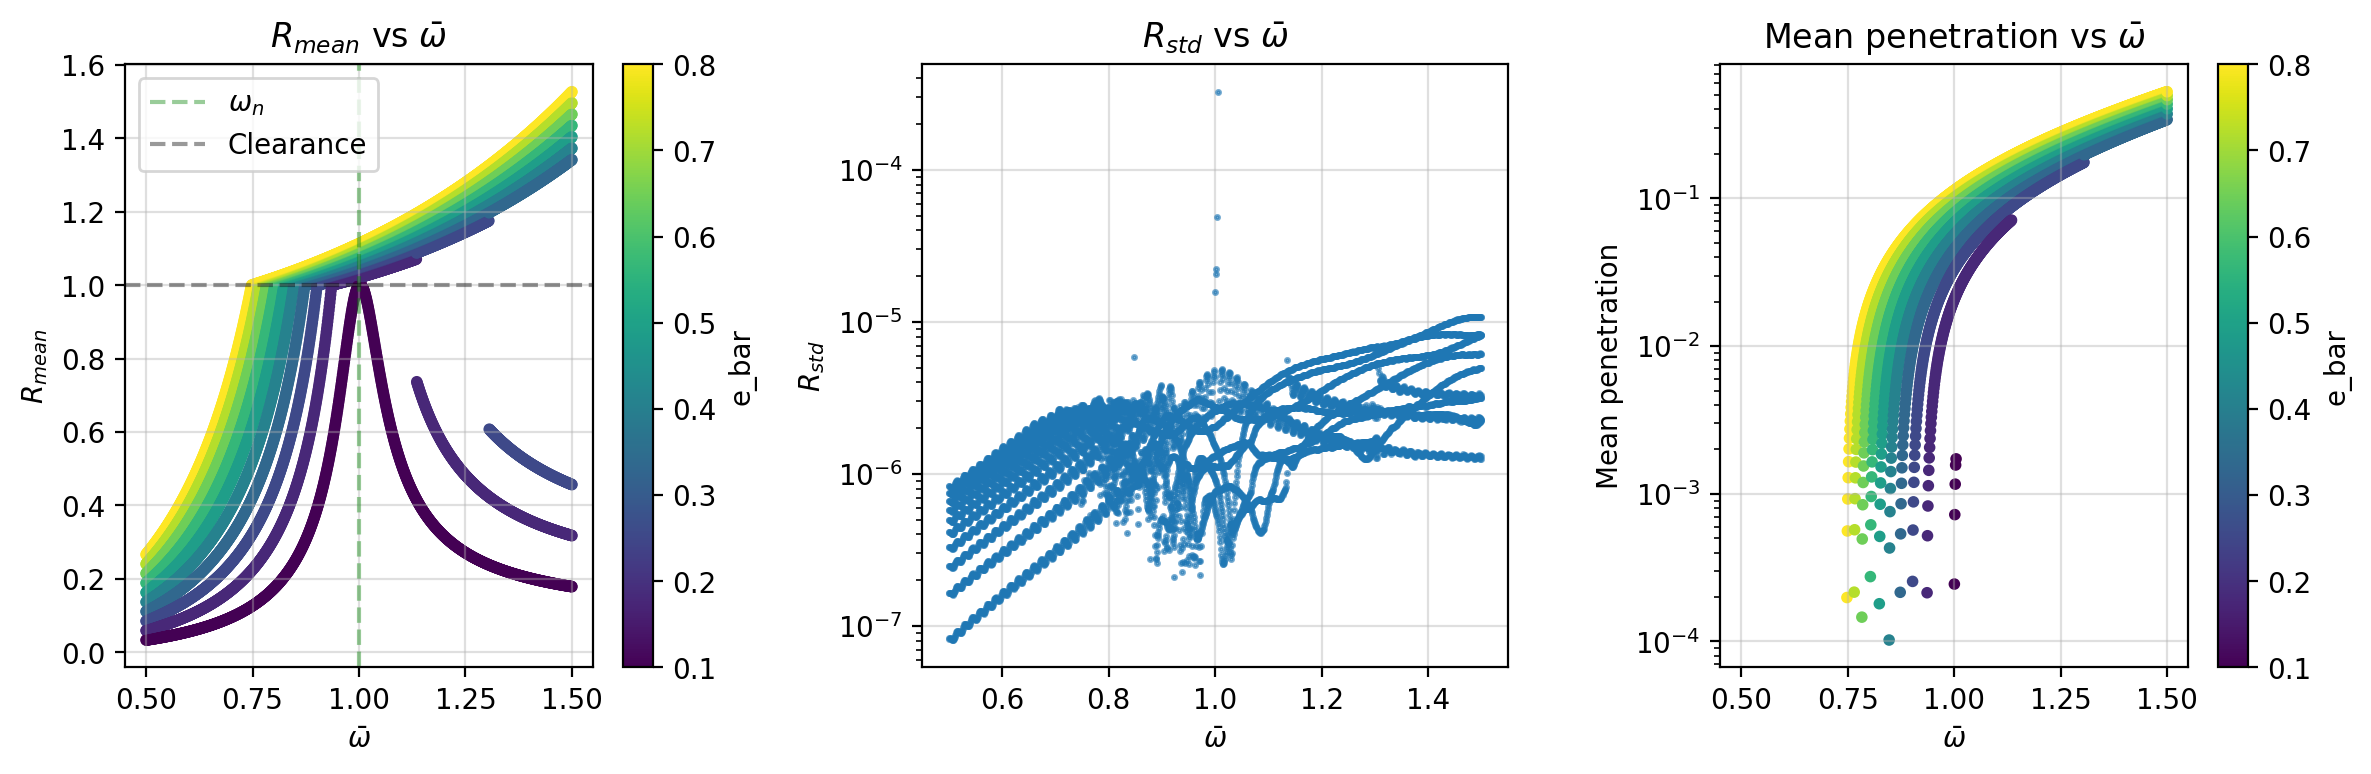

In [55]:
dfp = df.sort_values(['Omega_bar', 'e_bar'])

fig, ax = plt.subplots(1, 3, figsize=(12, 4))

sc0 = ax[0].scatter(dfp['Omega_bar'], dfp['R_mean'], c=dfp['e_bar'], s=10)
fig.colorbar(sc0, ax=ax[0], label='e_bar')
ax[0].set_title(r'$R_{mean}$ vs $\bar{\omega}$')
ax[0].axvline(x=1, color='green', linestyle='--', alpha=0.4, label=r'$\omega_n$')
ax[0].axhline(y=1, color='k', linestyle='--', alpha=0.4, label='Clearance')
ax[0].set_xlabel(r'$\bar{\omega}$')
ax[0].set_ylabel(r'$R_{mean}$')
ax[0].legend()
ax[0].grid(alpha=0.4)

ax[1].plot(dfp['Omega_bar'], dfp['R_std'], '.', ms=3, alpha=0.6)
# ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[1].set_title(r'$R_{std}$ vs $\bar{\omega}$')
ax[1].set_xlabel(r'$\bar{\omega}$')
ax[1].set_ylabel(r'$R_{std}$')
ax[1].grid(alpha=0.4)

sc2 = ax[2].scatter(dfp['Omega_bar'], dfp['penetration_mean'], c=dfp['e_bar'], s=10)
ax[2].set_yscale('log')
fig.colorbar(sc2, ax=ax[2], label='e_bar')
ax[2].set_title(r'Mean penetration vs $\bar{\omega}$')
ax[2].set_xlabel(r'$\bar{\omega}$')
ax[2].set_ylabel('Mean penetration')
ax[2].grid(alpha=0.4)

plt.tight_layout()


### Paper reference (validation)

- Your sweep plots summarize the transition in a way comparable to the paper’s amplitude–speed trends:
  - `papers/main.pdf` **Fig. 12** (PDF p. 9): with/without rub-impact amplitude comparison.
  - `papers/main.pdf` **Fig. 19** (PDF p. 13): amplitude during speed-ascending for different constraint states.
- The qualitative match to look for: near $\bar{\omega}\approx 1$, larger response + stronger/nonlinear contact effects; constraint state changes the amplitude trend.


## Interpreting the sweep plots

- **$R_{mean}$ vs $\bar{\omega}$ (left):** average orbit radius in steady state. Values approaching/exceeding $R=1$ indicate the response is spending significant time at/over the clearance boundary, i.e. rubbing is likely/active. The color ($e_{bar}$) highlights that larger imbalance generally increases the mean radius.

- **$R_{std}$ vs $\bar{\omega}$ (middle, log–log):** variability of the orbit radius. A rise near $\bar{\omega}\approx 1$ is a hallmark of the critical-speed region and/or intermittent contact: the response becomes more sensitive and non-linear effects (rubbing) increase fluctuations.

- **Mean penetration vs $\bar{\omega}$ (right, log y):** $\langle\max(R-1,0)\rangle$ is a direct measure of contact severity. Near-zero means mostly free whirl; increasing penetration indicates deeper/more sustained rubbing. Higher $e_{bar}$ typically increases penetration for the same $\bar{\omega}$.


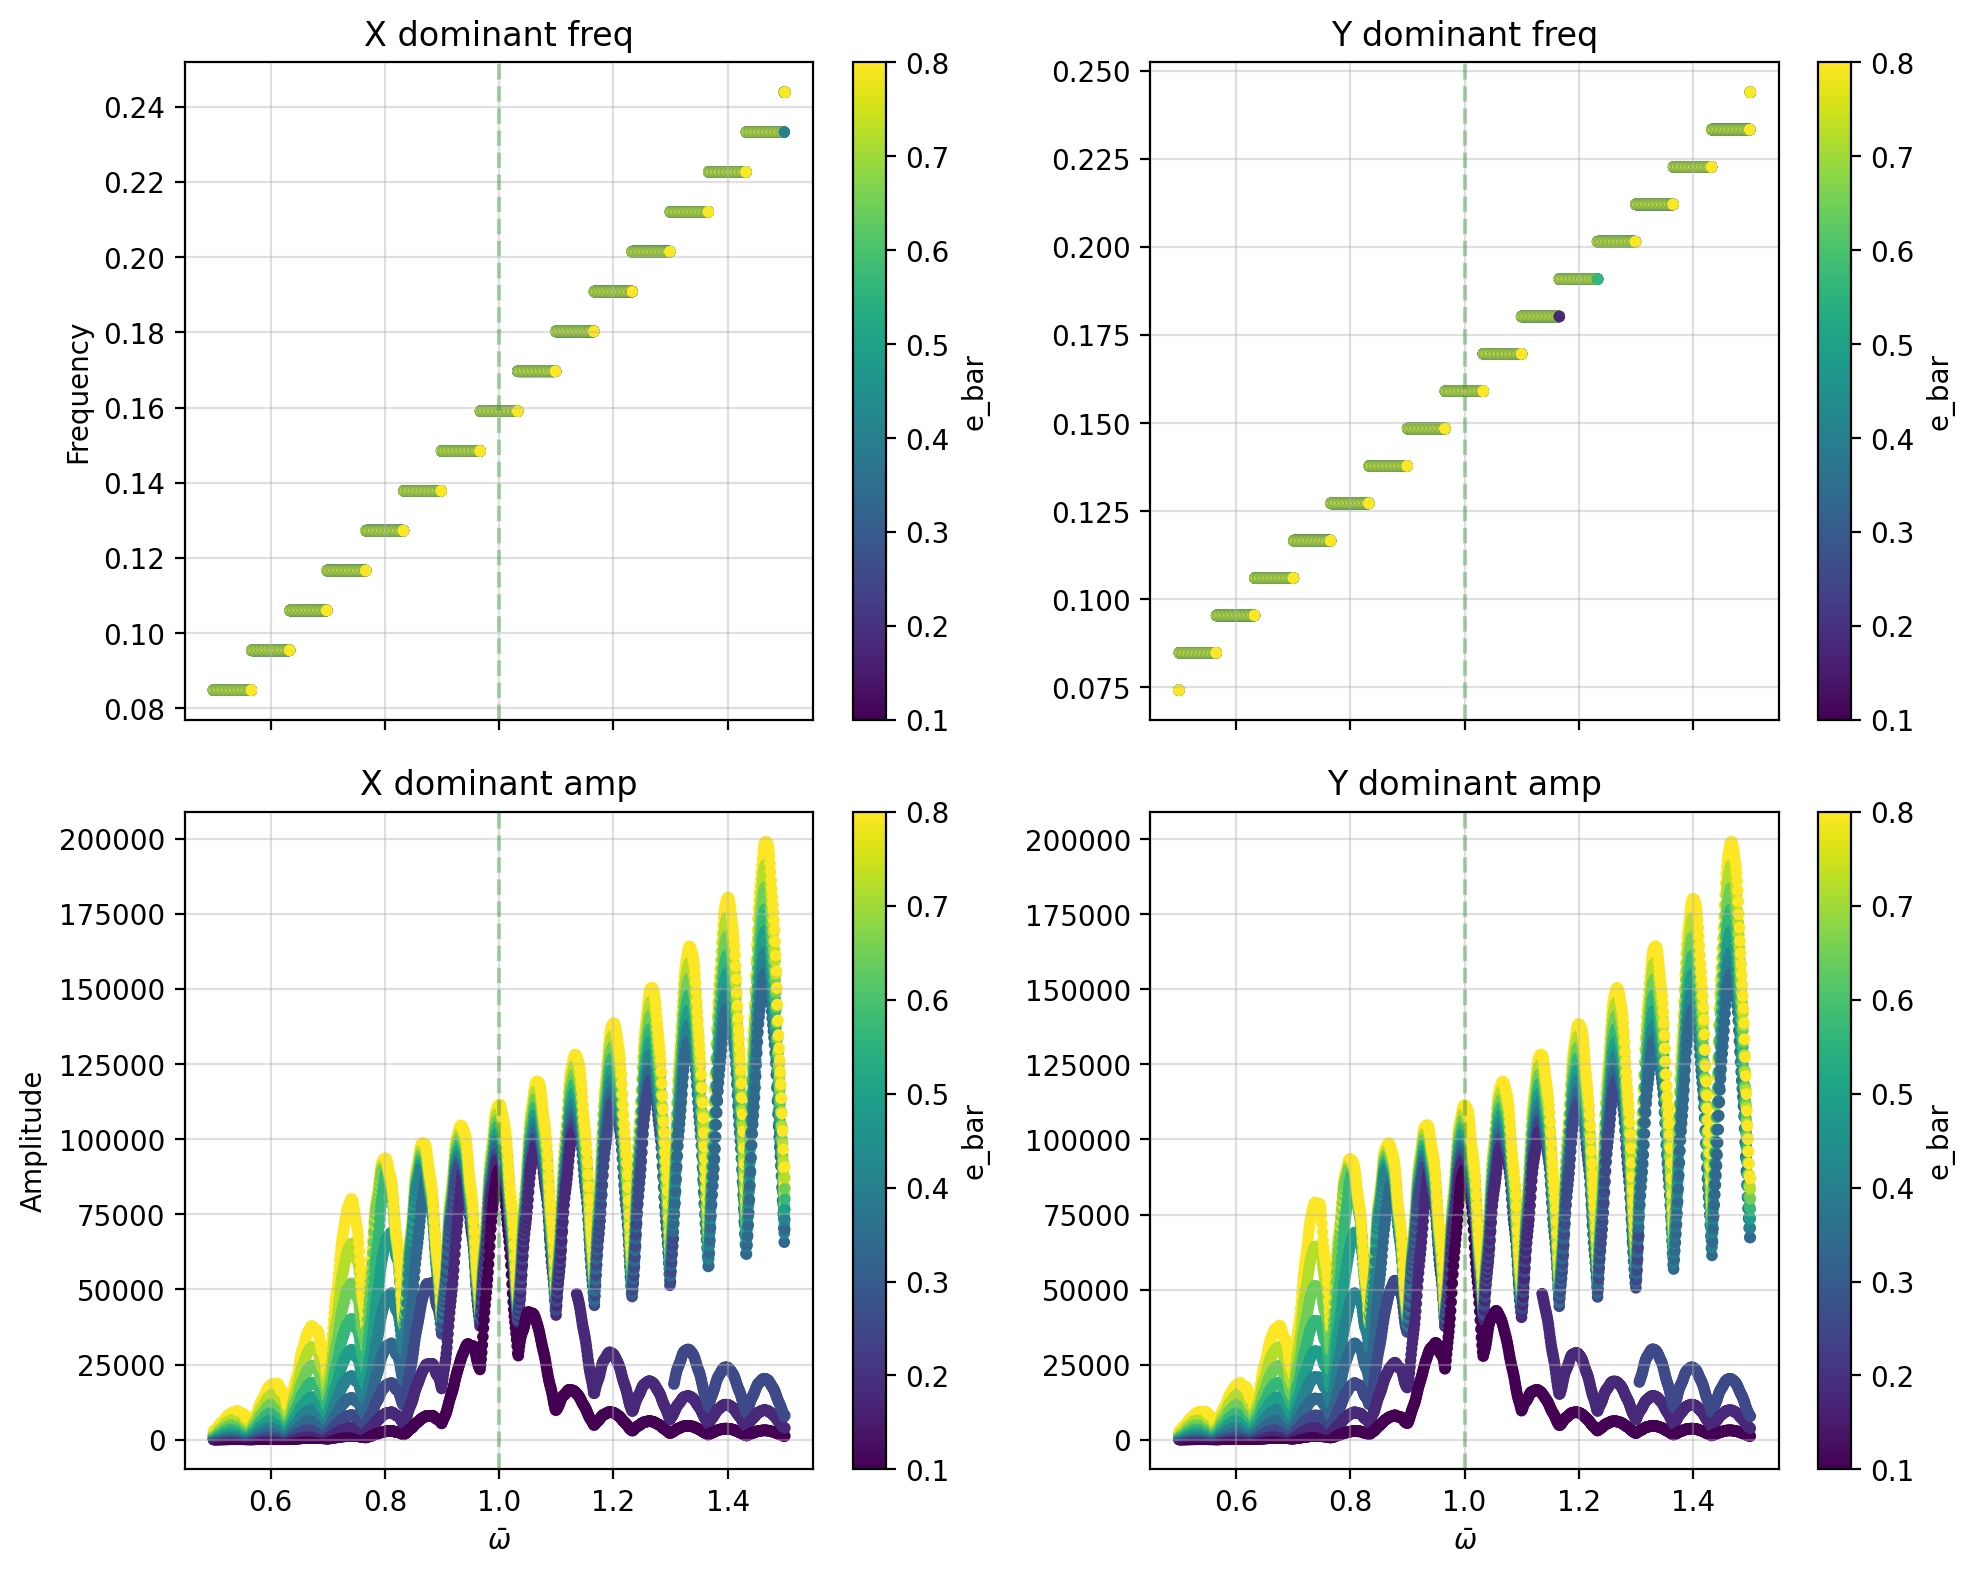

In [56]:
dfp = df.sort_values(['Omega_bar', 'e_bar'])

fig, ax = plt.subplots(2, 2, figsize=(10, 8), sharex=True)
norm = colors.Normalize(vmin=dfp['e_bar'].min(), vmax=dfp['e_bar'].max())

sc00 = ax[0, 0].scatter(dfp['Omega_bar'], dfp['x_dom_freq'], c=dfp['e_bar'], s=10, norm=norm, cmap='viridis')
ax[0, 0].axvline(1, color='green', linestyle='--', alpha=0.3)
ax[0, 0].set_title('X dominant freq')
ax[0, 0].set_ylabel('Frequency')
ax[0, 0].grid(alpha=0.4)
fig.colorbar(sc00, ax=ax[0, 0], label='e_bar')

sc01 = ax[0, 1].scatter(dfp['Omega_bar'], dfp['y_dom_freq'], c=dfp['e_bar'], s=10, norm=norm, cmap='viridis')
ax[0, 1].axvline(1, color='green', linestyle='--', alpha=0.3)
ax[0, 1].set_title('Y dominant freq')
ax[0, 1].grid(alpha=0.4)
fig.colorbar(sc01, ax=ax[0, 1], label='e_bar')

sc10 = ax[1, 0].scatter(dfp['Omega_bar'], dfp['x_dom_amp'], c=dfp['e_bar'], s=10, norm=norm, cmap='viridis')
ax[1, 0].axvline(1, color='green', linestyle='--', alpha=0.3)
ax[1, 0].set_title('X dominant amp')
ax[1, 0].set_xlabel(r'$\bar{\omega}$')
ax[1, 0].set_ylabel('Amplitude')
ax[1, 0].grid(alpha=0.4)
fig.colorbar(sc10, ax=ax[1, 0], label='e_bar')

sc11 = ax[1, 1].scatter(dfp['Omega_bar'], dfp['y_dom_amp'], c=dfp['e_bar'], s=10, norm=norm, cmap='viridis')
ax[1, 1].axvline(1, color='green', linestyle='--', alpha=0.3)
ax[1, 1].set_title('Y dominant amp')
ax[1, 1].set_xlabel(r'$\bar{\omega}$')
ax[1, 1].grid(alpha=0.4)
fig.colorbar(sc11, ax=ax[1, 1], label='e_bar')

plt.tight_layout()


### Paper reference (validation)

- These frequency-domain summaries can be cross-checked against the paper’s frequency–speed results:
  - `papers/main.pdf` **Fig. 7** (PDF p. 6): *Campbell diagram for rotors with/without non-smooth constraint*.
  - `papers/main.pdf` **Fig. 8** (PDF p. 7): *Influence of constraint stiffness on modal frequencies for different rotation speed ratios*.
- Expectation: in the constrained/rubbing regime, dominant components may **shift or scatter** due to non-smooth contact and energy redistribution (harmonics/instability regions discussed around Fig. 10).


## Interpreting the spectral plots

These plots summarize the steady-state frequency content of $X(\tau)$ and $Y(\tau)$ after transient removal.

- **Dominant frequency (top row):** the frequency at which the FFT magnitude is maximum in each channel. In a primarily synchronous/free-whirl regime, the dominant component tends to track the forcing/rotation-related component; as rubbing becomes stronger (non-linear regime), the dominant component can shift, broaden, or show more scatter (energy redistribution, modulation, sub/super-harmonics).

- **Dominant amplitude (bottom row):** the magnitude of that dominant spectral component. Growth around $\bar{\omega}\approx 1$ indicates stronger oscillatory response near the critical region. Saturation or qualitative changes with $\bar{\omega}$ can indicate that contact/rubbing is limiting the motion and altering how energy is distributed across frequencies.

Color indicates $e_{bar}$: larger imbalance typically increases spectral amplitudes and can trigger contact at lower $\bar{\omega}$.
